# 2D Quasi-Geostrophic model — tutorial

How to drive the integrator in `QG_2D.py`: run it with different parameter
settings, access derived fields (streamfunction, velocity), and visualize
snapshots and bulk diagnostics.

The prognostic variable is the relative vorticity $q$ on a doubly-periodic
$N\times N$ grid; the model solves

$$\frac{\partial q}{\partial t} + J(\psi,q) + \beta\,\frac{\partial\psi}{\partial x}
   = F - \mu\,q - \nu(-\nabla^2)^p q .$$

Make sure `QG_2D.py` is in the same directory as this notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from QG_2D import QG2D

## 1. A single run with the default forced–dissipative settings

`run(...)` integrates the model and returns an `xarray.Dataset` with dims
`(time, y, x)`; the model settings are stored in `ds.attrs`, and passing
`path=...` also writes a netCDF file.

In [2]:
m = QG2D(N=64, beta=0.0, mu=0.1, nu=1e-3, p=2, A=4.0, k_f=4)

q0 = m.random_ic(seed=0, amp=2.0)        # smooth random initial vorticity
ds = m.run(q0, tf=60, dt=0.01,           # integrate 60 time units, step 0.01
           spinup=40,                    # discard 40 units of spin-up first
           store_every=20,               # keep every 20th step
           path="qg_default.nc")         # also save to netCDF

ds

PermissionError: [Errno 13] Permission denied: b'c:\\Users\\serg_\\OneDrive\\\xd0\xa0\xd0\xb0\xd0\xb1\xd0\xbe\xd1\x87\xd0\xb8\xd0\xb9 \xd1\x81\xd1\x82\xd0\xbe\xd0\xbb\\ML_Project\\ML_aug_DA_2d_QG_case_study\\qg_default.nc'

Snapshot of vorticity and the diagnosed streamfunction at the final time:

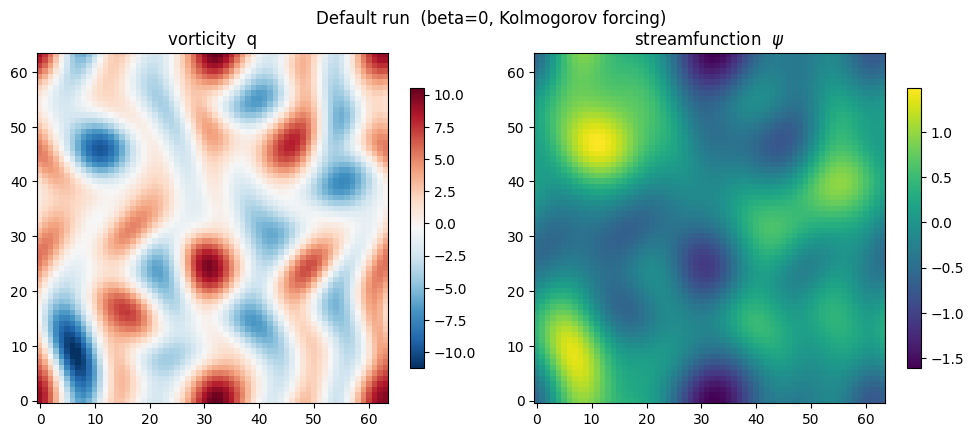

In [3]:
qf = ds.q.isel(time=-1).values
psi = m.streamfunction(qf)

fig, ax = plt.subplots(1, 2, figsize=(10, 4.2))
im0 = ax[0].imshow(qf, cmap="RdBu_r", origin="lower")
ax[0].set_title("vorticity  q")
fig.colorbar(im0, ax=ax[0], shrink=0.8)
im1 = ax[1].imshow(psi, cmap="viridis", origin="lower")
ax[1].set_title(r"streamfunction  $\psi$")
fig.colorbar(im1, ax=ax[1], shrink=0.8)
fig.suptitle("Default run  (beta=0, Kolmogorov forcing)")
fig.tight_layout()
plt.show()

## 2. Bulk diagnostics

Energy $E=\tfrac12\langle|\mathbf{u}|^2\rangle$ and enstrophy
$Z=\tfrac12\langle q^2\rangle$ over the stored trajectory.

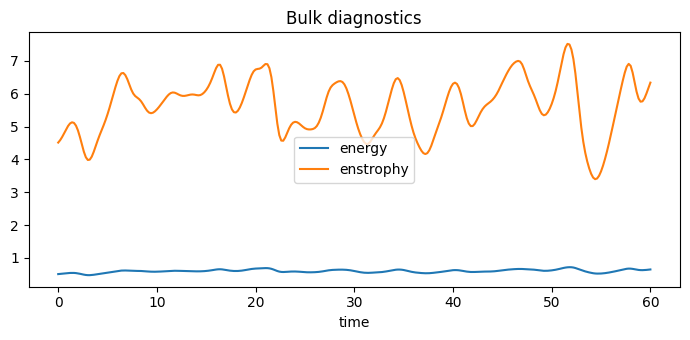

In [4]:
energy = np.array([m.energy(q) for q in ds.q.values])
enstrophy = np.array([m.enstrophy(q) for q in ds.q.values])

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(ds.time, energy, label="energy")
ax.plot(ds.time, enstrophy, label="enstrophy")
ax.set_xlabel("time")
ax.legend()
ax.set_title("Bulk diagnostics")
fig.tight_layout()
plt.show()

## 3. Parameter sweep: the planetary vorticity gradient $\beta$

Larger $\beta$ drives the flow from isotropic turbulence toward zonal (banded)
structure — Rossby waves and jets.

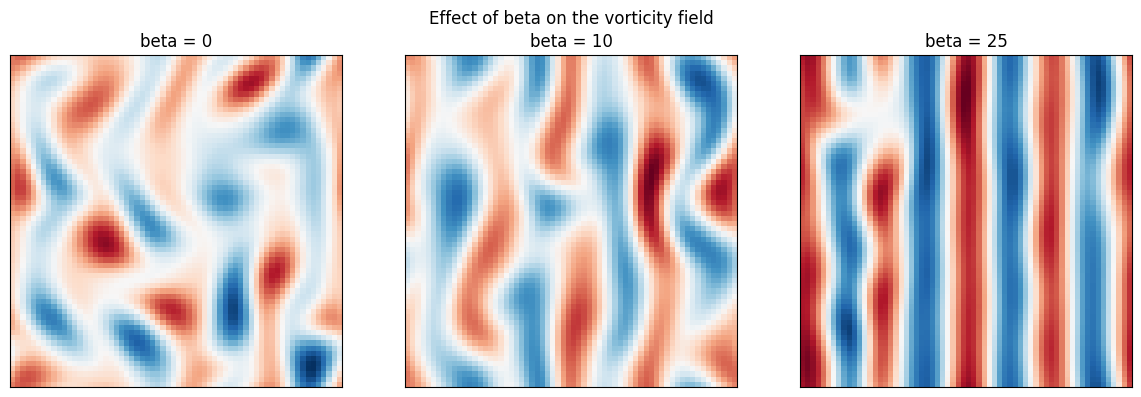

In [5]:
settings = {
    "beta = 0":   dict(beta=0.0),
    "beta = 10":  dict(beta=10.0),
    "beta = 25":  dict(beta=25.0),
}

fig, axes = plt.subplots(1, len(settings), figsize=(4 * len(settings), 4))
for ax, (label, override) in zip(axes, settings.items()):
    model = QG2D(N=64, mu=0.1, nu=1e-3, p=2, A=4.0, k_f=4, **override)
    run = model.run(model.random_ic(seed=0, amp=2.0),
                    tf=40, dt=0.008, spinup=40, store_every=50)
    field = run.q.isel(time=-1).values
    vmax = np.abs(field).max()
    ax.imshow(field, cmap="RdBu_r", origin="lower", vmin=-vmax, vmax=vmax)
    ax.set_title(label)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Effect of beta on the vorticity field")
fig.tight_layout()
plt.show()

## 4. Other knobs worth playing with

```python
m = QG2D(k_f=6)        # forcing wavenumber: smaller eddies
m = QG2D(A=8.0)        # stronger forcing: more energetic / turbulent
m = QG2D(mu=0.02)      # weaker drag: energy accumulates at large scales
m = QG2D(nu=5e-4, p=2) # weaker hyperviscosity: sharper small-scale features
m = QG2D(N=128)        # higher resolution (slower; may need smaller dt)
```

Reload a saved run later with:

```python
import xarray as xr
ds = xr.open_dataset("qg_default.nc")   # settings are in ds.attrs
```